# Modelado de Machine Learning: Predicción de Intención de Compra
## Online Shoppers Purchasing Intention Dataset

**Objetivo:** Construir un modelo de clasificación binaria que prediga si un usuario completará una compra (Revenue=True/False) basado en el comportamiento de navegación.

# 0 - Imports y Configuración Inicial

In [1]:
# Librerías de datos y ML
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import joblib

# Métricas y evaluación
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import os

print("✓ Todas las librerías importadas correctamente")

✓ Todas las librerías importadas correctamente


# FASE 1: Preprocesamiento de Datos

## 1.1 Carga de Datos y Limpieza Inicial

In [2]:
# Definir rutas
dir_raw = os.path.join('..', '..', 'data', 'raw')
dir_processed = os.path.join('..', '..', 'data', 'processed')
dir_models = os.path.join('..', '..', 'models')

# Crear directorios si no existen
os.makedirs(dir_processed, exist_ok=True)
os.makedirs(dir_models, exist_ok=True)

# Cargar datos
ruta_archivo = os.path.join(dir_raw, 'online_shoppers_intention.csv')
df = pd.read_csv(ruta_archivo)

print(f"Dataset original: {df.shape}")
print(f"Registros: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"\nPrimeras filas:\n{df.head()}")

Dataset original: (12330, 18)
Registros: 12330, Columnas: 18

Primeras filas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb  

## 1.2 Eliminar Registros Duplicados

In [3]:
# Verificar duplicados
n_duplicados = df.duplicated().sum()
print(f"Registros duplicados detectados: {n_duplicados}")

# Eliminar duplicados
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape[0]} registros")
print(f"✓ Duplicados eliminados exitosamente")

Registros duplicados detectados: 125
Dataset después de eliminar duplicados: 12205 registros
✓ Duplicados eliminados exitosamente


## 1.3 Separar Features Numéricas y Categóricas

In [4]:
# Definir columnas
numeric_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

categorical_features = [
    'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
    'VisitorType', 'Weekend'
]

target = 'Revenue'

print(f"Features Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"\nFeatures Categóricas ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget: {target}")

# Verificar tipos de datos
print(f"\n--- Tipos de Datos ---")
print(f"Numéricos: {df[numeric_features].dtypes.unique()}")
print(f"Categóricos: {df[categorical_features].dtypes.unique()}")
print(f"Target: {df[target].dtype}")

Features Numéricas (10): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Features Categóricas (7): ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Target: Revenue

--- Tipos de Datos ---
Numéricos: [dtype('int64') dtype('float64')]
Categóricos: [<StringDtype(na_value=nan)> dtype('int64') dtype('bool')]
Target: bool


## 1.4 Preparar Features y Target

In [5]:
# Separar X e y
X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

# Convertir y a valores numéricos (True/False -> 1/0)
y = y.astype(int)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nDistribución de target:")
print(y.value_counts())
print(f"\nProporción:")
print(y.value_counts(normalize=True) * 100)

# Verificar ausencia de nulos
print(f"\nValores nulos en X: {X.isnull().sum().sum()}")
print(f"Valores nulos en y: {y.isnull().sum()}")

X shape: (12205, 17)
y shape: (12205,)

Distribución de target:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Proporción:
Revenue
0    84.367063
1    15.632937
Name: proportion, dtype: float64

Valores nulos en X: 0
Valores nulos en y: 0


## 1.5 Guardar Dataset Limpio (Antes de Transformaciones)

In [6]:
# Reconstruir dataframe con datos limpios
df_clean = pd.concat([X, y], axis=1)

# Guardar
ruta_clean = os.path.join(dir_processed, 'online_shoppers_intention_clean.csv')
df_clean.to_csv(ruta_clean, index=False)

print(f"✓ Dataset limpio guardado en: {ruta_clean}")
print(f"Tamaño: {df_clean.shape}")

✓ Dataset limpio guardado en: ..\..\data\processed\online_shoppers_intention_clean.csv
Tamaño: (12205, 18)


## 1.6 Train-Test Split (Estratificado)

In [7]:
# Split 80/20 estratificado por target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribución Train:")
print(y_train.value_counts())
print(f"\nDistribución Test:")
print(y_test.value_counts())
print(f"\n✓ Split realizado correctamente con estratificación")

Train set: (9764, 17)
Test set: (2441, 17)

Distribución Train:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Distribución Test:
Revenue
0    2059
1     382
Name: count, dtype: int64

✓ Split realizado correctamente con estratificación


# FASE 2: Estrategia para Desbalance y Setup de Validación Cruzada

## 2.1 Configuración de Validación Cruzada Estratificada

In [8]:
# StratifiedKFold(5 folds) - preserva distribución de clases
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario de métricas para cross-validate
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("✓ StratifiedKFold configurado con 5 folds")
print(f"✓ Métricas a evaluar: {list(scoring_metrics.keys())}")
print(f"\nNota: Se usa desbalance intacto (no remuestreo)")
print(f"Enfoque: métricas robustas (F1, ROC-AUC, Recall)")

✓ StratifiedKFold configurado con 5 folds
✓ Métricas a evaluar: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

Nota: Se usa desbalance intacto (no remuestreo)
Enfoque: métricas robustas (F1, ROC-AUC, Recall)


## 2.2 Crear Preprocessor con ColumnTransformer

In [9]:
# ColumnTransformer para aplicar transformaciones selectivas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

print("✓ ColumnTransformer creado:")
print(f"  - StandardScaler para {len(numeric_features)} variables numéricas")
print(f"  - OneHotEncoder (drop='first', handle_unknown='ignore') para {len(categorical_features)} variables categóricas")
print(f"\nNota: drop='first' previene multicolinealidad perfecta en categóricas")
print(f"      handle_unknown='ignore' maneja categorías no vistas en entrenamiento")

# Ajustar el preprocessor solo con el conjunto de entrenamiento para evitar data leakage
print("Ajustando preprocessor sobre X_train (evitando data leakage)...")
preprocessor.fit(X_train)

# Transformar train y test con el preprocessor ajustado
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

# Construir nombres de columnas procesadas (numéricas + one-hot)
num_cols = numeric_features
cat_encoder = preprocessor.named_transformers_['cat']
try:
    ohe_cols = cat_encoder.get_feature_names_out(categorical_features)
except Exception:
    ohe_cols = [f"{c}_encoded" for c in categorical_features]
processed_cols = list(num_cols) + list(ohe_cols)

# Crear DataFrames procesados y guardarlos en data/processed
X_train_proc = pd.DataFrame(X_train_t, columns=processed_cols, index=X_train.index)
X_test_proc = pd.DataFrame(X_test_t, columns=processed_cols, index=X_test.index)
os.makedirs(dir_processed, exist_ok=True)
X_train_proc.to_csv(os.path.join(dir_processed, 'X_train_processed.csv'), index=True)
X_test_proc.to_csv(os.path.join(dir_processed, 'X_test_processed.csv'), index=True)
y_train.to_frame('Revenue').to_csv(os.path.join(dir_processed, 'y_train.csv'), index=True)
y_test.to_frame('Revenue').to_csv(os.path.join(dir_processed, 'y_test.csv'), index=True)
print("Guardados X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv en data/processed")

# Guardar el preprocessor ajustado para uso posterior
os.makedirs(dir_models, exist_ok=True)
joblib.dump(preprocessor, os.path.join(dir_models, 'preprocessor.pkl'))
print("Preprocessor guardado en models/preprocessor.pkl")

✓ ColumnTransformer creado:
  - StandardScaler para 10 variables numéricas
  - OneHotEncoder (drop='first', handle_unknown='ignore') para 7 variables categóricas

Nota: drop='first' previene multicolinealidad perfecta en categóricas
      handle_unknown='ignore' maneja categorías no vistas en entrenamiento
Ajustando preprocessor sobre X_train (evitando data leakage)...
Guardados X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv en data/processed
Preprocessor guardado en models/preprocessor.pkl


# FASE 3: Comparación de Modelos

## 3.1 Definir Modelos a Entrenar

In [10]:
# Diccionario de modelos (solo: Logistic Regression, Decision Tree, XGBoost)
# Calcular scale_pos_weight para XGBoost a partir del train set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
modelos = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False, scale_pos_weight=scale_pos_weight))
    ])
}

print("✓ Modelos definidos: Logistic Regression, Decision Tree, XGBoost")
for i, nombre in enumerate(modelos.keys(), 1):
    print(f"  {i}. {nombre}")

✓ Modelos definidos: Logistic Regression, Decision Tree, XGBoost
  1. Logistic Regression
  2. Decision Tree
  3. XGBoost


## 3.2 Entrenamiento y Validación Cruzada

In [11]:
# Diccionario para almacenar resultados
resultados_cv = {}
modelos_entrenados = {}

print("Entrenando modelos con Validación Cruzada (5-Fold)...\n")
print("=" * 100)

for nombre, modelo in modelos.items():
    print(f"\n▶ {nombre}")
    
    # Cross-validate
    cv_results = cross_validate(
        modelo, X_train, y_train,
        cv=skf,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=-1
    )
    
    # Almacenar resultados
    resultados_cv[nombre] = cv_results
    
    # Entrenar en todo el train set para evaluación posterior
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo
    
    # Mostrar estadísticas
    for metrica in scoring_metrics.keys():
        scores = cv_results[f'test_{metrica}']
        print(f"  {metrica.upper():12} -> Media: {scores.mean():.4f} ± {scores.std():.4f}")

print(f"\n{'='*100}")
print("✓ Entrenamiento completado")

Entrenando modelos con Validación Cruzada (5-Fold)...


▶ Logistic Regression
  ACCURACY     -> Media: 0.8819 ± 0.0046
  PRECISION    -> Media: 0.7443 ± 0.0301
  RECALL       -> Media: 0.3729 ± 0.0269
  F1           -> Media: 0.4963 ± 0.0266
  ROC_AUC      -> Media: 0.8889 ± 0.0125

▶ Decision Tree
  ACCURACY     -> Media: 0.8602 ± 0.0059
  PRECISION    -> Media: 0.5525 ± 0.0200
  RECALL       -> Media: 0.5609 ± 0.0127
  F1           -> Media: 0.5565 ± 0.0137
  ROC_AUC      -> Media: 0.7383 ± 0.0074

▶ XGBoost
  ACCURACY     -> Media: 0.8846 ± 0.0033
  PRECISION    -> Media: 0.6150 ± 0.0123
  RECALL       -> Media: 0.7012 ± 0.0204
  F1           -> Media: 0.6550 ± 0.0092
  ROC_AUC      -> Media: 0.9182 ± 0.0047

✓ Entrenamiento completado


## 3.3 Evaluar en Test Set

In [12]:
# Diccionario para almacenar métricas de test
resultados_test = {}

print("Evaluación en Test Set\n")
print("=" * 100)

for nombre, modelo in modelos_entrenados.items():
    print(f"\n▶ {nombre}")
    
    # Predicciones
    y_pred = modelo.predict(X_test)
    # Safe predict_proba: fallback a decision_function si es necesario
    if hasattr(modelo, 'predict_proba'):
        y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        if hasattr(modelo, 'decision_function'):
            scores = modelo.decision_function(X_test)
            y_pred_proba = (scores - scores.min()) / (scores.max() - scores.min())
        else:
            y_pred_proba = None

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else float('nan')

    # Almacenar
    resultados_test[nombre] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

    # Mostrar
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")

print(f"\n{'='*100}")
print("✓ Evaluación en test set completada")

Evaluación en Test Set


▶ Logistic Regression
  Accuracy : 0.8878
  Precision: 0.7571
  Recall   : 0.4162
  F1-Score : 0.5372
  ROC-AUC  : 0.8997

▶ Decision Tree
  Accuracy : 0.8566
  Precision: 0.5388
  Recall   : 0.5812
  F1-Score : 0.5592
  ROC-AUC  : 0.7444

▶ XGBoost
  Accuracy : 0.8820
  Precision: 0.6022
  Recall   : 0.7251
  F1-Score : 0.6580
  ROC-AUC  : 0.9205

✓ Evaluación en test set completada


## 3.4 Tabla Comparativa de Modelos

In [13]:
# Crear tabla comparativa
tabla_comparacion = pd.DataFrame({
    'Modelo': list(resultados_test.keys()),
    'Accuracy': [resultados_test[m]['accuracy'] for m in resultados_test.keys()],
    'Precision': [resultados_test[m]['precision'] for m in resultados_test.keys()],
    'Recall': [resultados_test[m]['recall'] for m in resultados_test.keys()],
    'F1-Score': [resultados_test[m]['f1'] for m in resultados_test.keys()],
    'ROC-AUC': [resultados_test[m]['roc_auc'] for m in resultados_test.keys()]
})

# Ordenar por ROC-AUC (descendente)
tabla_comparacion = tabla_comparacion.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\n=== TABLA COMPARATIVA DE MODELOS (Test Set) ===")
print(tabla_comparacion.to_string(index=False))

# Identificar ganador
ganador = tabla_comparacion.iloc[0]['Modelo']
roc_auc_ganador = tabla_comparacion.iloc[0]['ROC-AUC']
recall_ganador = tabla_comparacion.iloc[0]['Recall']

print(f"\n🏆 MODELO GANADOR: {ganador}")
print(f"   ROC-AUC: {roc_auc_ganador:.4f}")
print(f"   Recall: {recall_ganador:.4f}")


=== TABLA COMPARATIVA DE MODELOS (Test Set) ===
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost  0.882016   0.602174 0.725131  0.657957 0.920474
Logistic Regression  0.887751   0.757143 0.416230  0.537162 0.899665
      Decision Tree  0.856616   0.538835 0.581152  0.559194 0.744437

🏆 MODELO GANADOR: XGBoost
   ROC-AUC: 0.9205
   Recall: 0.7251


## 3.5 Visualizar Comparación (ROC Curves)

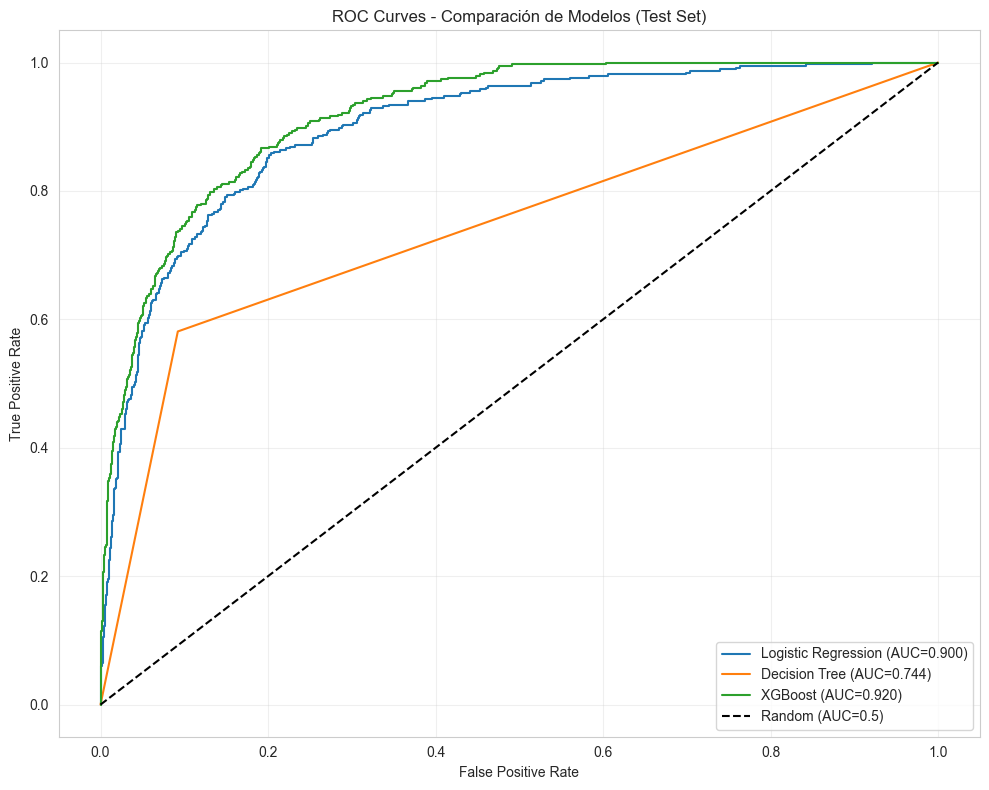

✓ Gráfico de ROC curves guardado


In [14]:
# Graficar ROC curves
plt.figure(figsize=(10, 8))

for nombre in resultados_test.keys():
    y_pred_proba = resultados_test[nombre]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = resultados_test[nombre]['roc_auc']
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})")

# Diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Comparación de Modelos (Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dir_models, 'roc_curves_comparacion.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico de ROC curves guardado")

# FASE 4: Evaluación del Modelo Ganador

## 4.1 Matriz de Confusión del Ganador

In [15]:
# Obtener predicciones del ganador
y_pred_ganador = resultados_test[ganador]['y_pred']

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_ganador)
tn, fp, fn, tp = cm.ravel()

print(f"\n=== MATRIZ DE CONFUSIÓN - {ganador.upper()} ===")
print(f"\nMatriz:")
print(cm)
print(f"\nDesglose:")
print(f"  TP (Verdaderos Positivos - Compras correctamente predichas): {tp}")
print(f"  TN (Verdaderos Negativos - No-compras correctamente predichas): {tn}")
print(f"  FP (Falsos Positivos - No-compras predichas como compra): {fp}")
print(f"  FN (Falsos Negativos - Compras predichas como no-compra): {fn}")

# Tasas
print(f"\n--- Análisis de Negocio ---")
print(f"  Compras detectadas correctamente: {tp} de {tp+fn} (Recall={recall_ganador:.1%})")
print(f"  Compras PERDIDAS (FN): {fn} sesiones")
print(f"  Falso positivo (False Alarm): {fp} sesiones sin compra predichas como compra")


=== MATRIZ DE CONFUSIÓN - XGBOOST ===

Matriz:
[[1876  183]
 [ 105  277]]

Desglose:
  TP (Verdaderos Positivos - Compras correctamente predichas): 277
  TN (Verdaderos Negativos - No-compras correctamente predichas): 1876
  FP (Falsos Positivos - No-compras predichas como compra): 183
  FN (Falsos Negativos - Compras predichas como no-compra): 105

--- Análisis de Negocio ---
  Compras detectadas correctamente: 277 de 382 (Recall=72.5%)
  Compras PERDIDAS (FN): 105 sesiones
  Falso positivo (False Alarm): 183 sesiones sin compra predichas como compra


## 4.2 Visualizar Matriz de Confusión

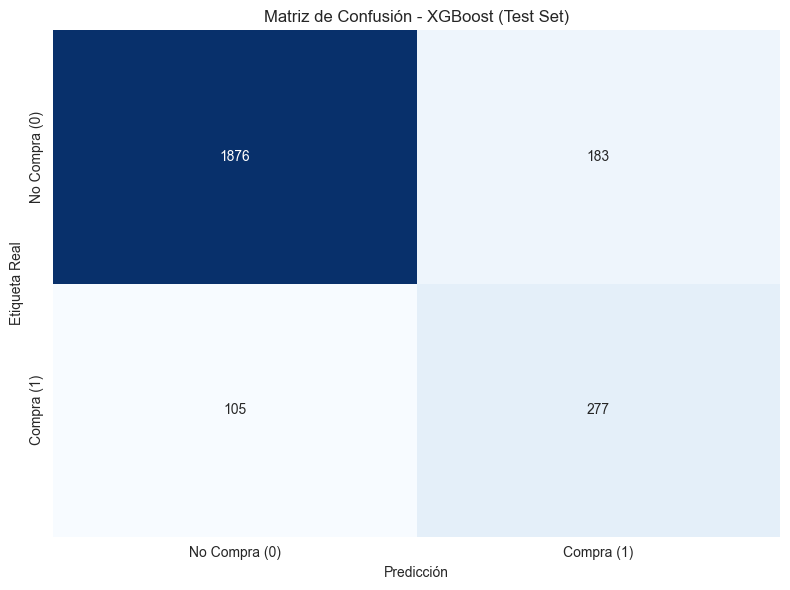

✓ Matriz de confusión guardada


In [16]:
# Heatmap de matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Compra (0)', 'Compra (1)'],
            yticklabels=['No Compra (0)', 'Compra (1)'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.title(f'Matriz de Confusión - {ganador} (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(dir_models, f'confusion_matrix_{ganador.replace(" ", "_").lower()}.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Matriz de confusión guardada")

## 4.3 Reporte de Clasificación Detallado

In [17]:
# Reporte de clasificación
reporte = classification_report(y_test, y_pred_ganador, target_names=['No Compra', 'Compra'])
print(f"\n=== REPORTE DE CLASIFICACIÓN - {ganador.upper()} ===")
print(reporte)


=== REPORTE DE CLASIFICACIÓN - XGBOOST ===
              precision    recall  f1-score   support

   No Compra       0.95      0.91      0.93      2059
      Compra       0.60      0.73      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.82      0.79      2441
weighted avg       0.89      0.88      0.89      2441



## 4.4 ROC Curve del Ganador

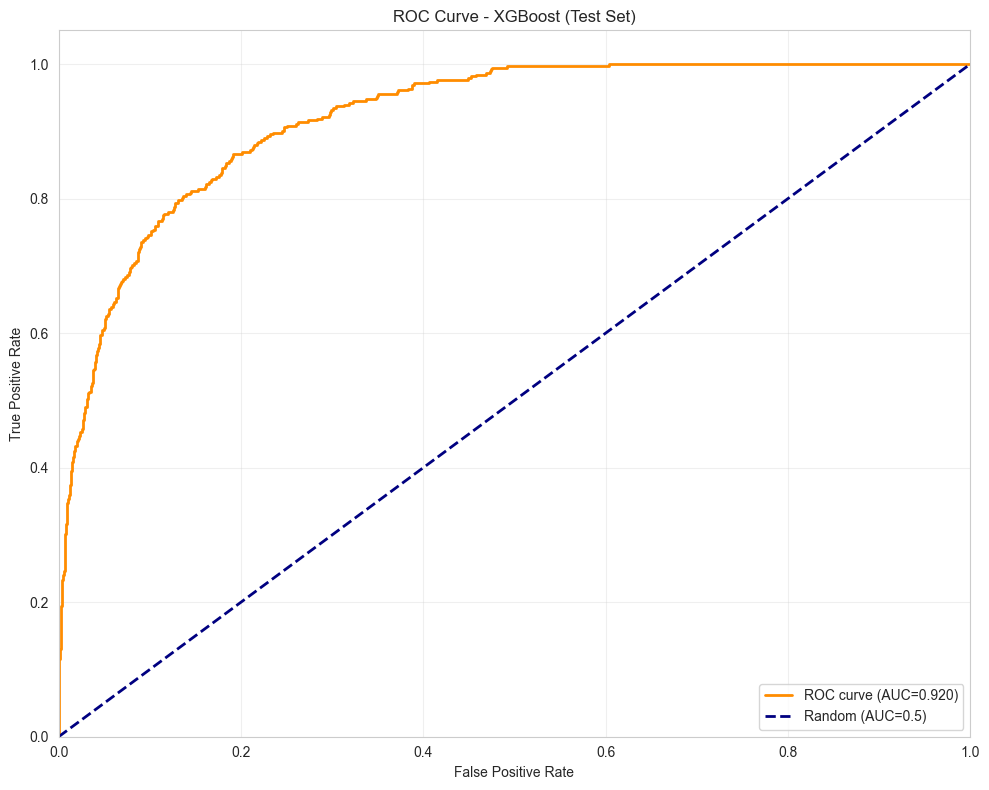

✓ ROC curve guardado


In [18]:
# ROC curve para el ganador
y_pred_proba_ganador = resultados_test[ganador]['y_pred_proba']
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_ganador)
roc_auc_ganador = roc_auc_score(y_test, y_pred_proba_ganador)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc_ganador:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {ganador} (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dir_models, f'roc_curve_{ganador.replace(" ", "_").lower()}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve guardado")

## 4.5 Feature Importance (si aplica)


=== TOP 20 FEATURES MÁS IMPORTANTES - XGBoost ===
                feature  importance
             PageValues    0.163681
              Month_Nov    0.088000
              Month_Mar    0.072545
              Month_May    0.066425
              Month_Jul    0.024658
             Browser_12    0.023577
              Month_Sep    0.020720
         TrafficType_13    0.019222
              Month_Dec    0.019105
          TrafficType_5    0.016462
          TrafficType_3    0.016131
ProductRelated_Duration    0.015229
          TrafficType_8    0.014373
              Month_Feb    0.014248
               Region_5    0.014024
            BounceRates    0.013984
               Region_4    0.013888
Administrative_Duration    0.013864
          TrafficType_2    0.013775
         TrafficType_11    0.013711


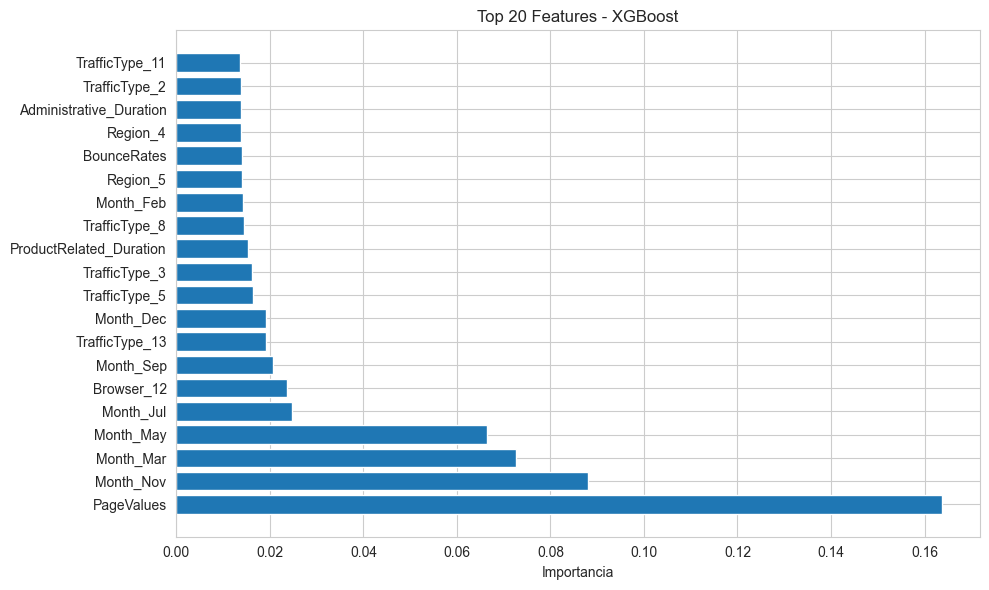

✓ Feature importance guardado


In [19]:
# Intentar extraer feature importance si el modelo lo tiene
modelo_ganador = modelos_entrenados[ganador]

try:
    # Obtener el clasificador del pipeline
    clf = modelo_ganador.named_steps['clf']
    
    # Para Random Forest y XGBoost
    if hasattr(clf, 'feature_importances_'):
        # Obtener nombres de features después del preprocessor
        preprocessor = modelo_ganador.named_steps['preprocessor']
        
        # Nombres de features después de one-hot encoding
        cat_encoder = preprocessor.named_transformers_['cat']
        cat_features = cat_encoder.get_feature_names_out(categorical_features)
        all_features = list(numeric_features) + list(cat_features)
        
        # Feature importance
        feature_importance = pd.DataFrame({
            'feature': all_features,
            'importance': clf.feature_importances_
        }).sort_values('importance', ascending=False).head(20)
        
        print(f"\n=== TOP 20 FEATURES MÁS IMPORTANTES - {ganador} ===")
        print(feature_importance.to_string(index=False))
        
        # Visualizar
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(feature_importance)), feature_importance['importance'])
        plt.yticks(range(len(feature_importance)), feature_importance['feature'])
        plt.xlabel('Importancia')
        plt.title(f'Top 20 Features - {ganador}')
        plt.tight_layout()
        plt.savefig(os.path.join(dir_models, f'feature_importance_{ganador.replace(" ", "_").lower()}.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Feature importance guardado")
    else:
        print(f"\n⚠ {ganador} no tiene atributo 'feature_importances_'")
        print("  (Típicamente disponible en modelos basados en árboles)")
        
except Exception as e:
    print(f"⚠ Error al extraer feature importance: {e}")

## 4.6 Guardar Modelo Ganador

In [20]:
# Guardar modelo
ruta_modelo = os.path.join(dir_models, 'modelo_ganador.pkl')
joblib.dump(modelo_ganador, ruta_modelo)

print(f"✓ Modelo '{ganador}' guardado en: {ruta_modelo}")

✓ Modelo 'XGBoost' guardado en: ..\..\models\modelo_ganador.pkl


## 4.7 Guardar Resumen del Modelo Ganador

In [21]:
from datetime import datetime

# Crear resumen
resumen = f"""
================================================================================
RESUMEN DEL MODELO GANADOR - PREDICCIÓN DE INTENCIÓN DE COMPRA
================================================================================

FECHA DE GENERACIÓN: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

MODELO SELECCIONADO: {ganador}
================================================================================

1. MÉTRICAS EN TEST SET
  - Accuracy : {resultados_test[ganador]['accuracy']:.4f}
  - Precision: {resultados_test[ganador]['precision']:.4f}
  - Recall   : {resultados_test[ganador]['recall']:.4f}
  - F1-Score : {resultados_test[ganador]['f1']:.4f}
  - ROC-AUC  : {resultados_test[ganador]['roc_auc']:.4f}

2. MATRIZ DE CONFUSIÓN
  TP (Verdaderos Positivos) : {tp}
  TN (Verdaderos Negativos) : {tn}
  FP (Falsos Positivos)     : {fp}
  FN (Falsos Negativos)     : {fn}

3. ANÁLISIS DE NEGOCIO
  - Compras detectadas correctamente: {tp} de {tp+fn} ({recall_ganador:.1%})
  - Compras PERDIDAS (FN): {fn} sesiones
  - False Alarms (FP): {fp} sesiones

4. CONFIGURACIÓN DEL MODELO
  - Preprocesamiento:
    * StandardScaler en {len(numeric_features)} variables numéricas
    * OneHotEncoder (drop='first') en {len(categorical_features)} variables categóricas
  
  - Validación Cruzada: StratifiedKFold(n_splits=5)
  - Train/Test Split: 80/20 (estratificado por target)
  - Manejo de Desbalance: Métricas robustas (no remuestreo)

5. COMPARATIVA CON OTROS MODELOS
{tabla_comparacion.to_string(index=False)}

6. CÓMO USAR EL MODELO
  
  import joblib
  modelo = joblib.load('modelo_ganador.pkl')
  
  # X_nuevo debe tener las mismas columnas que el dataset de entrenamiento
  predicciones = modelo.predict(X_nuevo)
  probabilidades = modelo.predict_proba(X_nuevo)[:, 1]

7. ARCHIVOS GENERADOS
  - modelo_ganador.pkl : Modelo entrenado (pipeline completo)
  - confusion_matrix_*.png : Matriz de confusión
  - roc_curve_*.png : ROC curve del ganador
  - roc_curves_comparacion.png : ROC curves de todos los modelos
  - feature_importance_*.png : Importancia de features (si aplica)
  - resumen_modelo_ganador.txt : Este archivo

================================================================================
"""

# Guardar resumen
ruta_resumen = os.path.join(dir_models, 'resumen_modelo_ganador.txt')
with open(ruta_resumen, 'w', encoding='utf-8') as f:
    f.write(resumen)

print(f"✓ Resumen guardado en: {ruta_resumen}")
print("\n" + "="*80)
print(resumen)
print("="*80)

# Guardar informe de preprocesamiento en docs/
docs_dir = os.path.join('..', '..', 'docs')
os.makedirs(docs_dir, exist_ok=True)
report_path = os.path.join(docs_dir, 'preprocessing_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('Preprocessing report\n')
    f.write('Generated: ' + datetime.now().isoformat() + '\n')
    f.write('Numeric features: ' + str(numeric_features) + '\n')
    f.write('Categorical features: ' + str(categorical_features) + '\n')
    f.write('Processed files: ' + os.path.join(dir_processed, 'X_train_processed.csv') + ', ' + os.path.join(dir_processed, 'X_test_processed.csv') + '\n')
print(f"✓ Preprocessing report guardado en: {report_path}")

✓ Resumen guardado en: ..\..\models\resumen_modelo_ganador.txt


RESUMEN DEL MODELO GANADOR - PREDICCIÓN DE INTENCIÓN DE COMPRA

FECHA DE GENERACIÓN: 2026-05-25 15:31:20

MODELO SELECCIONADO: XGBoost

1. MÉTRICAS EN TEST SET
  - Accuracy : 0.8820
  - Precision: 0.6022
  - Recall   : 0.7251
  - F1-Score : 0.6580
  - ROC-AUC  : 0.9205

2. MATRIZ DE CONFUSIÓN
  TP (Verdaderos Positivos) : 277
  TN (Verdaderos Negativos) : 1876
  FP (Falsos Positivos)     : 183
  FN (Falsos Negativos)     : 105

3. ANÁLISIS DE NEGOCIO
  - Compras detectadas correctamente: 277 de 382 (72.5%)
  - Compras PERDIDAS (FN): 105 sesiones
  - False Alarms (FP): 183 sesiones

4. CONFIGURACIÓN DEL MODELO
  - Preprocesamiento:
    * StandardScaler en 10 variables numéricas
    * OneHotEncoder (drop='first') en 7 variables categóricas
  
  - Validación Cruzada: StratifiedKFold(n_splits=5)
  - Train/Test Split: 80/20 (estratificado por target)
  - Manejo de Desbalance: Métricas robustas (no remuestreo)

5. COMPARATIVA C

## 4.8 Verificación Final de Archivos

In [22]:
# Verificar archivos generados
print(f"\n=== VERIFICACIÓN DE ARCHIVOS GENERADOS ===")

print(f"\n▶ Directorio data/processed:")
if os.path.exists(dir_processed):
    for archivo in os.listdir(dir_processed):
        ruta_completa = os.path.join(dir_processed, archivo)
        tamaño = os.path.getsize(ruta_completa) / 1024  # KB
        print(f"  ✓ {archivo} ({tamaño:.2f} KB)")

print(f"\n▶ Directorio models:")
if os.path.exists(dir_models):
    for archivo in os.listdir(dir_models):
        if archivo != '.gitkeep':
            ruta_completa = os.path.join(dir_models, archivo)
            tamaño = os.path.getsize(ruta_completa) / 1024  # KB
            print(f"  ✓ {archivo} ({tamaño:.2f} KB)")

print(f"\n✓ Modelado completado exitosamente")


=== VERIFICACIÓN DE ARCHIVOS GENERADOS ===

▶ Directorio data/processed:
  ✓ online_shoppers_intention_clean.csv (1086.70 KB)
  ✓ X_test_processed.csv (1036.31 KB)
  ✓ X_train_processed.csv (4142.35 KB)
  ✓ y_test.csv (19.34 KB)
  ✓ y_train.csv (77.22 KB)

▶ Directorio models:
  ✓ confusion_matrix_xgboost.png (82.79 KB)
  ✓ feature_importance_xgboost.png (151.66 KB)
  ✓ modelo_ganador.pkl (306.38 KB)
  ✓ preprocessor.pkl (4.73 KB)
  ✓ resumen_modelo_ganador.txt (2.19 KB)
  ✓ roc_curves_comparacion.png (248.08 KB)
  ✓ roc_curve_xgboost.png (169.89 KB)

✓ Modelado completado exitosamente
